# 3F7 Full Technical Report: Experiments

**Objectives:**

1. Measure Entropy Rates ($H_n, H_n^*$) of a stationary source (Hamlet).
2. Evaluate Adaptive Arithmetic Coding convergence and parameter sensitivity ($\delta$).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from math import log2
import os

# 1. Setup & Data Loading
if not os.path.exists("images"):
    os.makedirs("images")


def load_hamlet():
    # Try likely paths
    paths = ["hamlet.txt", "../short-lab/hamlet.txt"]
    for p in paths:
        if os.path.exists(p):
            with open(p, "r") as f:
                return f.read()
    raise FileNotFoundError("hamlet.txt not found. Please upload it.")


hamlet = load_hamlet()
print(f"Loaded hamlet.txt: {len(hamlet)} characters")


# 2. Helper Functions
def get_entropy(data):
    counts = Counter(data)
    total = len(data)
    return -sum((c / total) * log2(c / total) for c in counts.values())


# 3. Global Baselines (Static Model)
# We need these for the red dashed lines in plots
H_1 = get_entropy(hamlet)
print(f"Static Entropy H_1: {H_1:.4f} bits/symbol")

alphabet_size = len(set(hamlet))
print(f"Alphabet size: {alphabet_size}")

Loaded hamlet.txt: 207039 characters
Static Entropy H_1: 4.4499 bits/symbol
Alphabet size: 67


## Part 1: Entropy Rate Measurements

We calculate $H_n = \frac{1}{n}H(X^n)$ and derive $H_n^*$.


Measuring block entropies up to n=100...


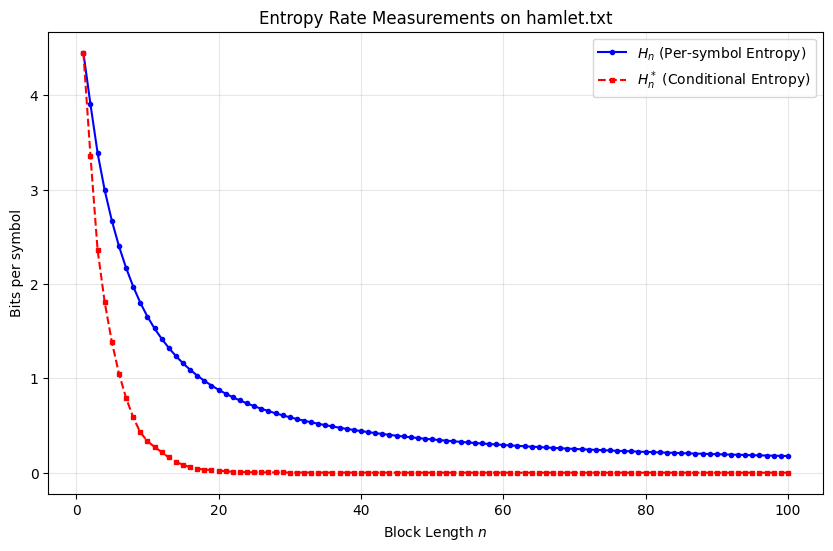

Values for report:
H_80 = 0.221
H_star_80 = 0.000


In [2]:
max_n = 100  # Going beyond 15-20 is slow and memory intensive
h_n = []

print(f"Measuring block entropies up to n={max_n}...")
for n in range(1, max_n + 1):
    # Count n-tuples
    tuples = [hamlet[i : i + n] for i in range(len(hamlet) - n + 1)]
    h_n.append(get_entropy(tuples) / n)

# Derive Conditional Entropy H*_n
# H*_n = n*H_n - (n-1)*H_{n-1}
h_star = [h_n[0]]  # H*_1 = H_1
for n in range(2, max_n + 1):
    val = n * h_n[n - 1] - (n - 1) * h_n[n - 2]
    h_star.append(val)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, max_n + 1), h_n, "b-o", label="$H_n$ (Per-symbol Entropy)", markersize=3
)
plt.plot(
    range(1, max_n + 1),
    h_star,
    "r--s",
    label="$H_n^*$ (Conditional Entropy)",
    markersize=3,
)
plt.title("Entropy Rate Measurements on hamlet.txt")
plt.xlabel("Block Length $n$")
plt.ylabel("Bits per symbol")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("images/entropy_rate_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Values for report:")
print(f"H_80 = {h_n[79]:.3f}")
print(f"H_star_80 = {h_star[79]:.3f}")

## Part 2: Adaptive Coding

### 2.1 Convergence ($L/n$ vs $n$)


In [ ]:
N_sim = 10000
delta = 1.0

# Initialize with pseudocounts (Dirichlet prior)
# We use the full known alphabet to ensure we don't crash on new symbols,
# effectively assuming the alphabet is known but distribution is not.
all_chars = list(set(hamlet))
counts = {c: delta for c in all_chars}
total_count = sum(counts.values())

L_history = []
total_L = 0

for i, char in enumerate(hamlet[:N_sim]):
    # 1. Encode (calculate probability using CURRENT model)
    p = counts[char] / total_count
    bits = -log2(p)
    total_L += bits
    L_history.append(total_L / (i + 1))

    # 2. Update Model
    counts[char] += 1
    total_count += 1

plt.figure(figsize=(10, 6))
plt.plot(L_history, label="Adaptive $L/n$")
plt.hlines(H_1, 0, N_sim, colors="r", linestyles="--", label="Static $H_1$")
plt.title(f"Convergence of Adaptive Coding (delta={delta})")
plt.xlabel("Sequence Length $n$")
plt.ylabel("Average Code Length (bits)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("images/adaptive_coding_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2 Parameter Sensitivity ($\delta$)


In [ ]:
deltas = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []

print("Testing deltas...")
for d in deltas:
    counts = {c: d for c in all_chars}
    total = sum(counts.values())
    L = 0
    for char in hamlet:
        p = counts[char] / total
        L += -log2(p)
        counts[char] += 1
        total += 1
    results.append(L / len(hamlet))
    print(f"delta={d}: {results[-1]:.4f} bits/sym")

optimal_delta = deltas[np.argmin(results)]

plt.figure(figsize=(10, 6))
plt.semilogx(deltas, results, "b-o")
plt.hlines(
    H_1, min(deltas), max(deltas), colors="r", linestyles="--", label="Static $H_1$"
)
plt.title("Effect of Bias Parameter $\delta$")
plt.xlabel("$\delta$")
plt.ylabel("Final Code Rate (bits/sym)")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig("images/delta_variation.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.3 Adaptive vs Non-Adaptive Comparison


In [ ]:
# File lengths to test (log scale)
lengths = np.logspace(2, np.log10(len(hamlet)), 50).astype(int)
lengths = sorted(list(set(lengths)))

# 1. Adaptive Cost (Cumulative)
# Run one pass with optimal delta
counts = {c: optimal_delta for c in all_chars}
total = sum(counts.values())
cum_L = 0
adaptive_costs = []
checkpoints = set(lengths)
cost_map = {}

for i, char in enumerate(hamlet):
    p = counts[char] / total
    cum_L += -log2(p)
    counts[char] += 1
    total += 1

    n = i + 1
    if n in checkpoints:
        cost_map[n] = cum_L

adaptive_y = [cost_map[n] for n in lengths]

# 2. Static Cost
# L = n * H_1 + Model_Overhead
# Model overhead ~ k * log2(n) (simple approximation for frequency table)
k = len(all_chars)
static_y = [n * H_1 + k * np.log2(n) for n in lengths]

plt.figure(figsize=(10, 6))
plt.loglog(lengths, adaptive_y, "b-", label="Adaptive (Total Bits)")
plt.loglog(lengths, static_y, "r--", label="Static + Model Cost")
plt.title("Adaptive vs Non-Adaptive Coding")
plt.xlabel("File Length (symbols)")
plt.ylabel("Total Size (bits)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.savefig("images/adaptive_vs_nonadaptive.png", dpi=300, bbox_inches="tight")
plt.show()